In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("3) Sentiment dataset.csv")

df.head()

Saving 3) Sentiment dataset.csv to 3) Sentiment dataset.csv


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (732, 15)

Columns:
Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='object')

Missing Values:
Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64


In [4]:
features = [
    'Likes',
    'Retweets',
    'Hour'
]

X = df[features]

print(X.head())

   Likes  Retweets  Hour
0   30.0      15.0    12
1   10.0       5.0     8
2   40.0      20.0    15
3   15.0       8.0    18
4   25.0      12.0    19


In [5]:
X = X.fillna(X.mean())

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

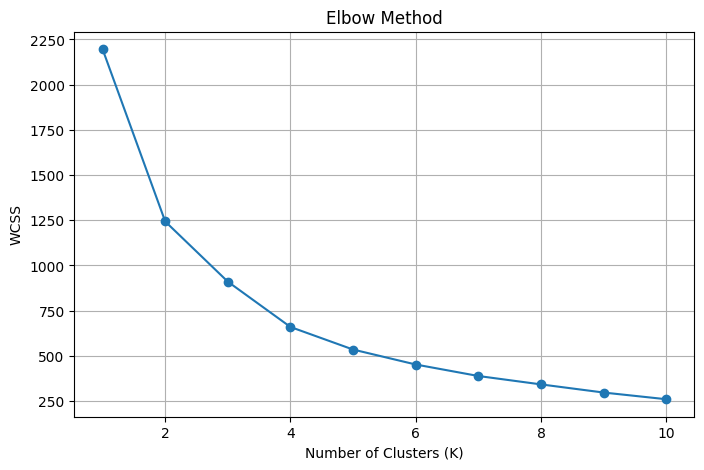

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [9]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [10]:
print(df['Cluster'].value_counts())

Cluster
0    230
2    189
1    177
3    136
Name: count, dtype: int64


In [11]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

cluster_centers = pd.DataFrame(
    centers,
    columns=features
)

print(cluster_centers)

       Likes   Retweets       Hour
0  40.960870  20.521739  18.695652
1  46.254237  23.192090  11.463277
2  26.857143  13.449735  13.698413
3  64.117647  32.183824  17.970588


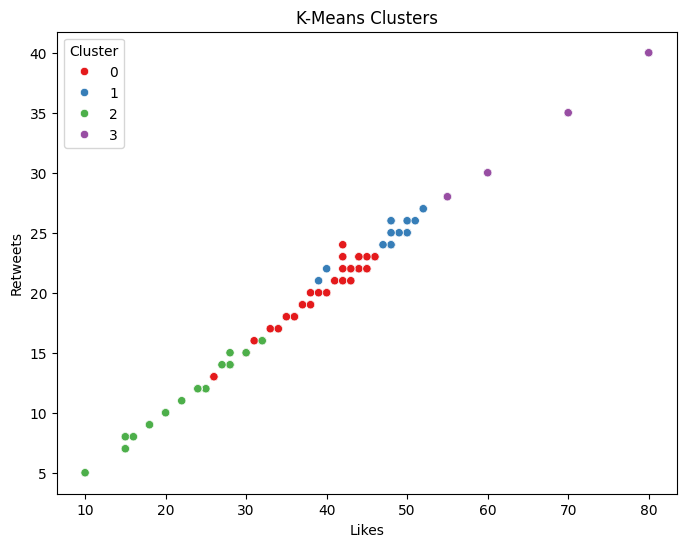

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Likes',
    y='Retweets',
    hue='Cluster',
    palette='Set1'
)

plt.title("K-Means Clusters")

plt.show()

In [13]:
summary = df.groupby('Cluster')[features].mean()

print(summary)

             Likes   Retweets       Hour
Cluster                                 
0        40.960870  20.521739  18.695652
1        46.254237  23.192090  11.463277
2        26.857143  13.449735  13.698413
3        64.117647  32.183824  17.970588


In [14]:
for cluster in sorted(df['Cluster'].unique()):

    print("\nCluster", cluster)

    print(
        df[df['Cluster']==cluster][features]
        .mean()
    )


Cluster 0
Likes       40.960870
Retweets    20.521739
Hour        18.695652
dtype: float64

Cluster 1
Likes       46.254237
Retweets    23.192090
Hour        11.463277
dtype: float64

Cluster 2
Likes       26.857143
Retweets    13.449735
Hour        13.698413
dtype: float64

Cluster 3
Likes       64.117647
Retweets    32.183824
Hour        17.970588
dtype: float64
